In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings("ignore")


**Exploratory Data Analysis**

In [3]:
# Exploratory Data Analysis
def load_and_explore_data(file_path):
    data = pd.read_csv(file_path)
    print("Dataset Shape:", data.shape)
    print("\nSample Data:\n", data.head())
    print("\nDataset Info:")
    print(data.info())
    print("\nMissing Values:\n", data.isnull().sum())
    return data

dataset = load_and_explore_data('mpii_dataset.csv')


Dataset Shape: (2281, 46)

Sample Data:
       head_x    head_y  head_vis  upper_neck_x  upper_neck_y  upper_neck_vis  \
0   597.3050  336.8551         1      634.6950      396.1449               1   
1   901.7261  302.4625         1      910.2739      378.5375               1   
2  1014.7766  357.2180         1     1029.2234      407.7820               1   
3   771.9307   95.9672         1      726.0693      210.0328               1   
4   353.2627  107.6864         1      325.7373      133.3136               1   

   thorax_x  thorax_y  thorax_vis  lsho_x  ...  rknee_x  rknee_y  rknee_vis  \
0       651       422           1     690  ...      582      572          1   
1       911       385           1     942  ...      875      545          0   
2      1033       421           1    1002  ...     1079      562          1   
3       710       250           0     697  ...      705      625          1   
4       325       134           0     319  ...      313      238          1   

   


Missing Values:
head_x            0
head_y            0
head_vis          0
upper_neck_x      0
upper_neck_y      0
upper_neck_vis    0
thorax_x          0
thorax_y          0
thorax_vis        0
lsho_x            0
lsho_y            0
lsho_vis          0
rsho_x            0
rsho_y            0
rsho_vis          0
lelb_x            0
lelb_y            0
lelb_vis          0
relb_x            0
relb_y            0
relb_vis          0
lwri_x            0
lwri_y            0
lwri_vis          0
rwri_x            0
rwri_y            0
rwri_vis          0
lhip_x            0
lhip_y            0
lhip_vis          0
rhip_x            0
rhip_y            0
rhip_vis          0
lknee_x           0
lknee_y           0
lknee_vis         0
rknee_x           0
rknee_y           0
rknee_vis         0
lankl_x           0
lankl_y           0
lankl_vis         0
rankl_x           0
rankl_y           0
rankl_vis         0
sport             0
dtype: int64


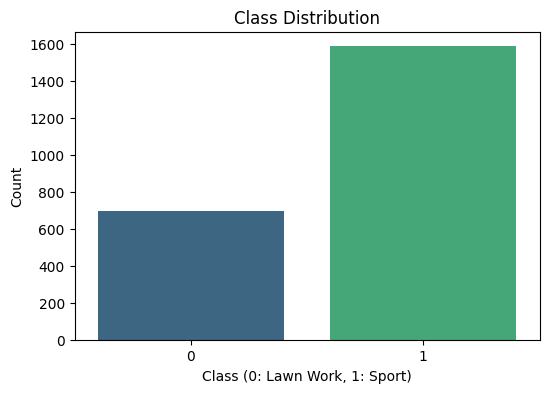

In [4]:
# Check for missing values
missing_values = dataset.isnull().sum()
print("\nMissing Values:")
print(missing_values)

# Plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = dataset['sport'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class (0: Lawn Work, 1: Sport)')
plt.ylabel('Count')
plt.show()

**Data Visualization (Class Distributions, Target class correlations, Feature plots)**

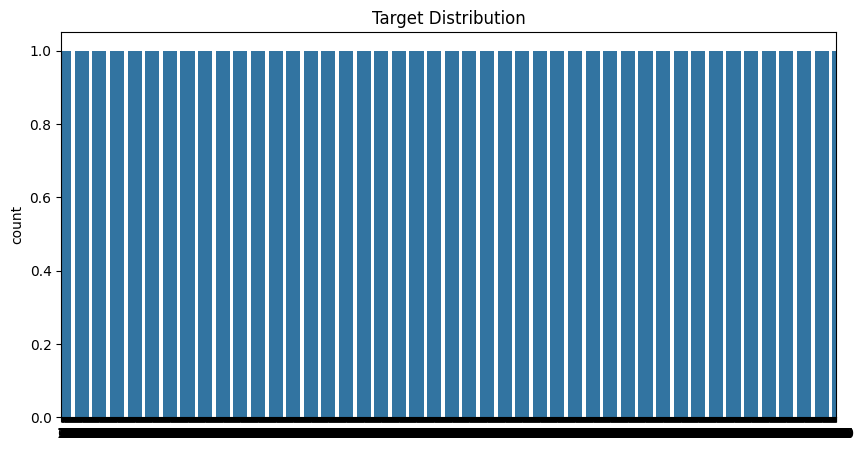

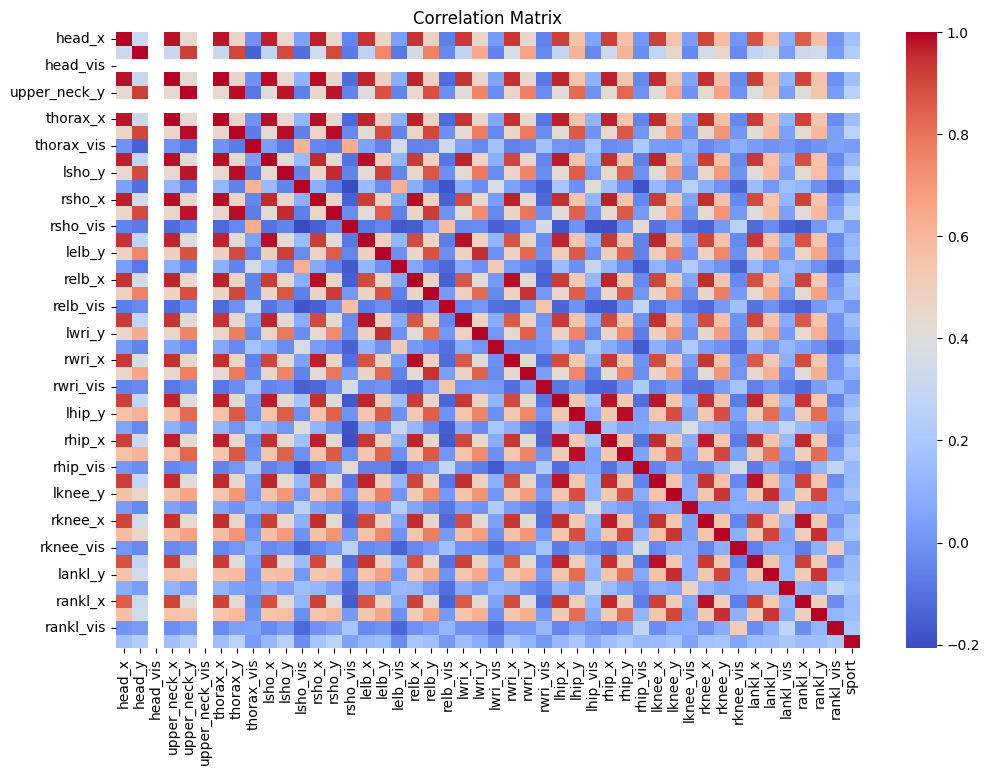

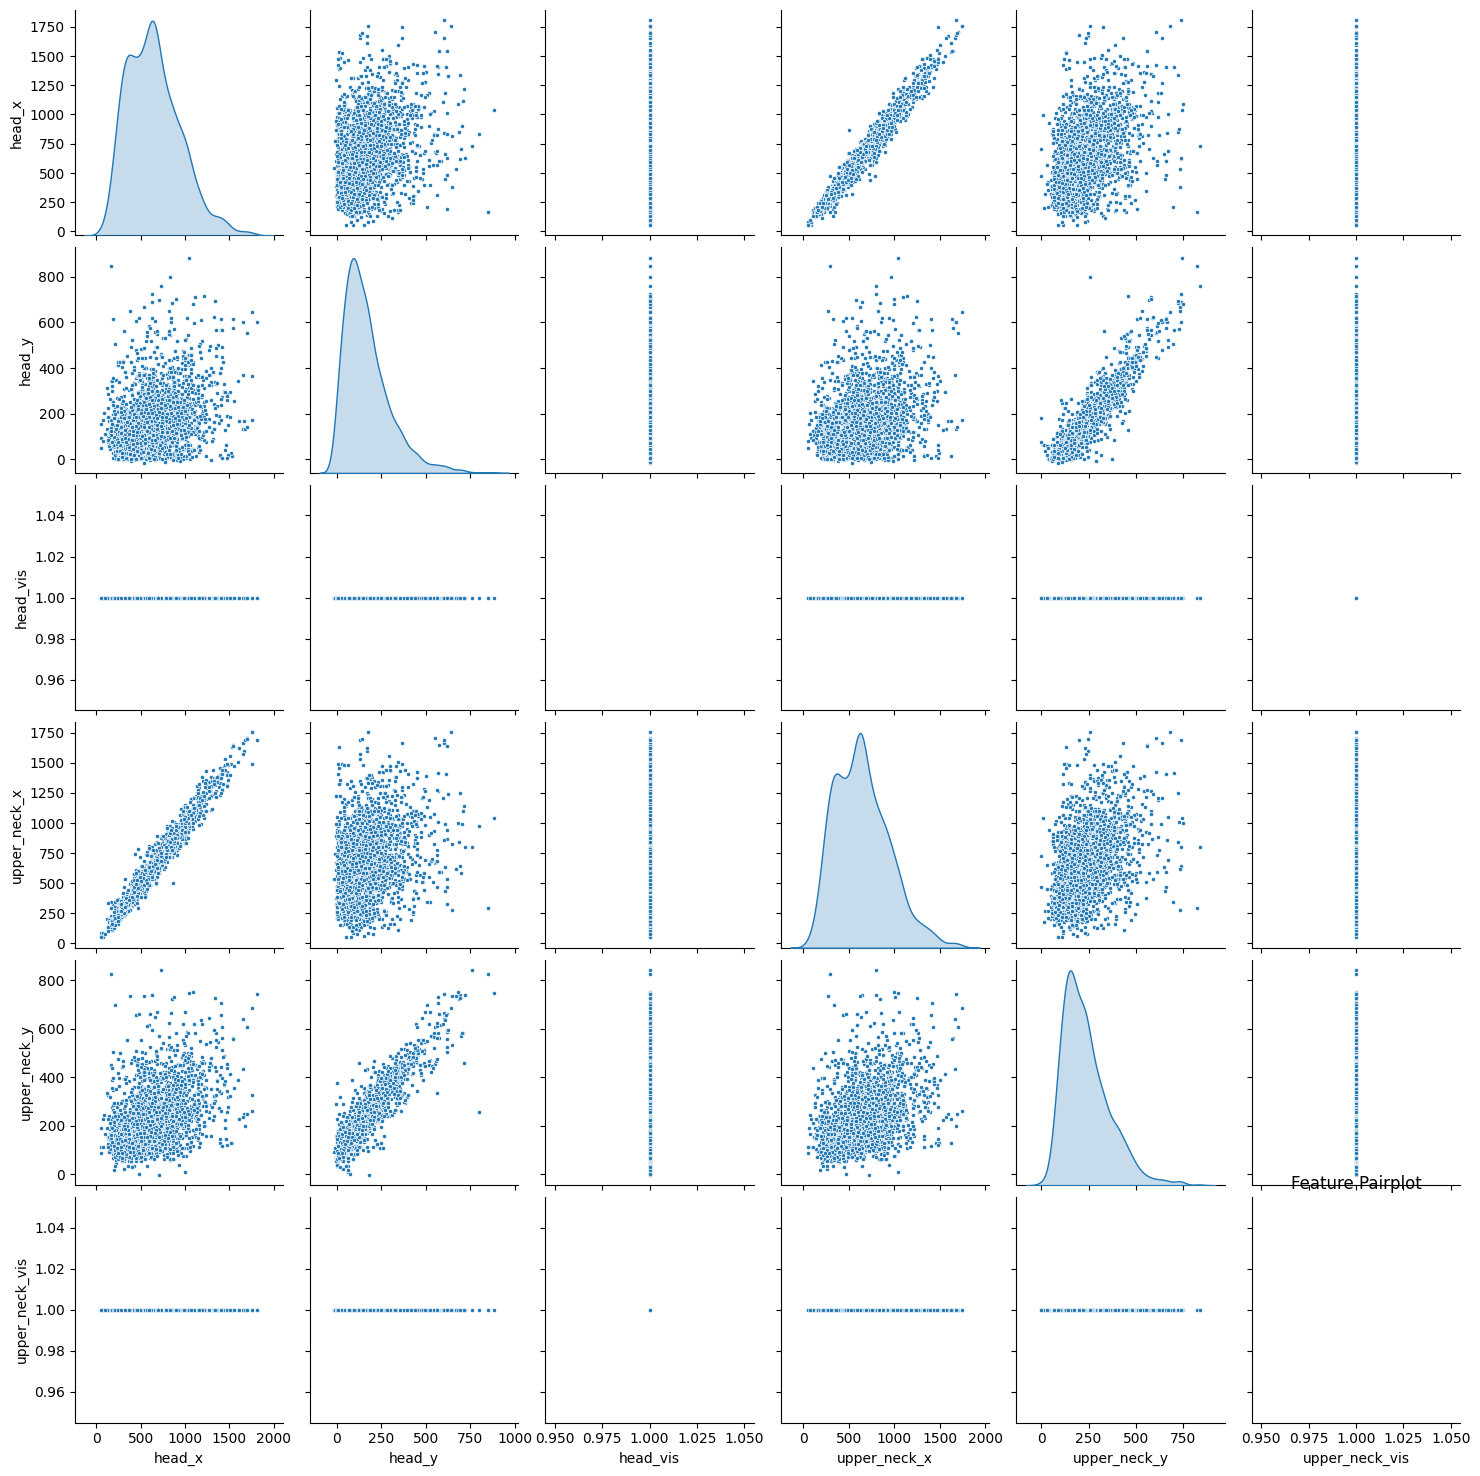

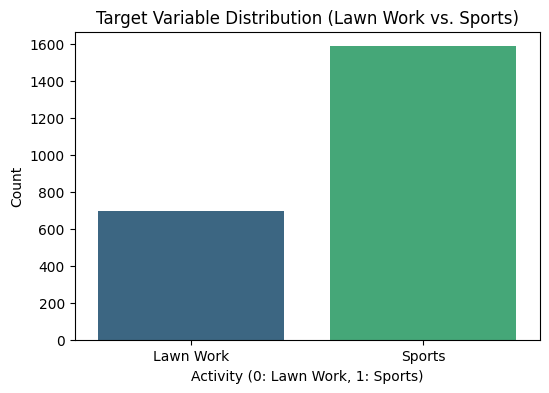

In [5]:
#Exploratory Data Analysis (EDA) and Visualization
def eda_visualization(data):
    # Target Variable Distribution
    plt.figure(figsize=(10, 5))
    sns.countplot(data['sport'])
    plt.title("Target Distribution")
    plt.show()

    # Correlation Matrix
    plt.figure(figsize=(12, 8))
    correlation = data.corr()
    sns.heatmap(correlation, annot=False, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()

    # Pairplot of first few features for simplicity
    sns.pairplot(data.iloc[:, :6], diag_kind='kde', markers='.')
    plt.title("Feature Pairplot")
    plt.show()
    # Target variable distribution
    target_counts = dataset['sport'].value_counts()

    # Plot the distribution of the target variable
    plt.figure(figsize=(6, 4))
    sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
    plt.title("Target Variable Distribution (Lawn Work vs. Sports)")
    plt.xlabel("Activity (0: Lawn Work, 1: Sports)")
    plt.ylabel("Count")
    plt.xticks([0, 1], ['Lawn Work', 'Sports'])
    plt.show()

# Summary statistics for numerical features
dataset.describe()
eda_visualization(dataset)


**Feature Engineering, Preprocessing**

In [6]:
#Feature Engineering
def feature_engineering(data):
    # Example Feature Engineering
    data['arm_length_left'] = np.sqrt((data['lsho_x'] - data['lelb_x'])**2 + (data['lsho_y'] - data['lelb_y'])**2)
    data['arm_length_right'] = np.sqrt((data['rsho_x'] - data['relb_x'])**2 + (data['rsho_y'] - data['relb_y'])**2)
    data['leg_length_left'] = np.sqrt((data['lhip_x'] - data['lknee_x'])**2 + (data['lhip_y'] - data['lknee_y'])**2)
    data['leg_length_right'] = np.sqrt((data['rhip_x'] - data['rknee_x'])**2 + (data['rhip_y'] - data['rknee_y'])**2)

    data['arm_symmetry'] = abs(data['arm_length_left'] - data['arm_length_right'])
    data['leg_symmetry'] = abs(data['leg_length_left'] - data['leg_length_right'])

    data['hand_distance'] = np.sqrt((data['lwri_x'] - data['rwri_x'])**2 + (data['lwri_y'] - data['rwri_y'])**2)
    data['foot_distance'] = np.sqrt((data['lankl_x'] - data['rankl_x'])**2 + (data['lankl_y'] - data['rankl_y'])**2)

    # Angle Feature
    data['angle_head_torso'] = (
        np.arctan2(data['thorax_y'] - data['head_y'], data['thorax_x'] - data['head_x'])
    )
    data['distance_head_neck'] = np.sqrt((data['head_x'] - data['upper_neck_x'])**2 + (data['head_y'] - data['upper_neck_y'])**2)

    return data

dataset = feature_engineering(dataset)


In [7]:
# Preprocessing and Splitting
def preprocess_and_split(data):
    X = data.drop(columns=['sport'])  # Features
    y = data['sport']  # Target

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Handle Imbalance with SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Scale Features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train_resampled, y_test

X_train, X_test, y_train, y_test = preprocess_and_split(dataset)


**Training Classifier - XGBoost (Boosting models)**

In [11]:
# Classifier Training and Hyperparameter Tuning
def train_xgboost(X_train, y_train):
    # Ensure y_train has unique classes
    num_classes = len(np.unique(y_train))  # Number of unique classes
    print("Number of Classes:", num_classes)

    # Define the XGBClassifier with num_class explicitly set
    xgb_model = xgb.XGBClassifier(
        objective='multi:softmax',  # For multi-class classification
        eval_metric='mlogloss',    # Evaluation metric
        use_label_encoder=False,
        num_class=num_classes      # number of classes
    )

    # Hyperparameter Grid
    param_dist = {
        'n_estimators': randint(50, 300),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
    }

    # Randomized Search
    random_search = RandomizedSearchCV(
        xgb_model, param_distributions=param_dist, n_iter=50, scoring='f1_weighted',
        cv=5, verbose=2, random_state=42, n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:", random_search.best_params_)
    return random_search.best_estimator_


best_model = train_xgboost(X_train, y_train)


Number of Classes: 2
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'colsample_bytree': 0.9179245214166594, 'learning_rate': 0.16079112793155764, 'max_depth': 14, 'min_child_weight': 1, 'n_estimators': 246, 'subsample': 0.6920741072966221}


In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Hyperparameter tuning
def train_xgboost(X_train, y_train):
    xgb_model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=2,  # Set based on your dataset
        use_label_encoder=False,
        eval_metric='mlogloss'
    )

    # Define hyperparameter search space
    param_dist = {
        'n_estimators': randint(50, 300),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
    }

    # Perform randomized search
    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,
        n_iter=50,
        scoring='f1_weighted',
        cv=5,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    return random_search

# Run hyperparameter tuning
random_search = train_xgboost(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [13]:
# Train the Best Model and Evaluate
# best parameters from the random search
best_xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    use_label_encoder=False,
    num_class=2,
    **random_search.best_params_

# Fit the best model on the entire training set
best_xgb_model.fit(X_train, y_train)

# Predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Evaluation Metrics
from sklearn.metrics import classification_report, f1_score

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Weighted F1-Score:", f1_score(y_test, y_pred, average='weighted'))


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.66      0.66       208
           1       0.85      0.86      0.85       477

    accuracy                           0.80       685
   macro avg       0.76      0.76      0.76       685
weighted avg       0.80      0.80      0.80       685

Weighted F1-Score: 0.7953405536692505


<Figure size 1000x800 with 0 Axes>

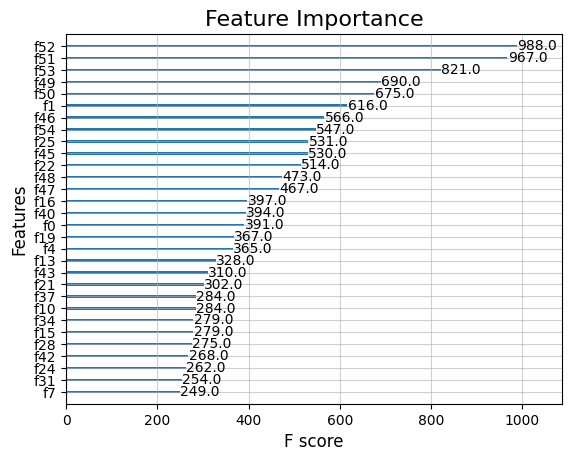

In [17]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importance with better readability
def plot_feature_importance(model):
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(model, importance_type='weight', max_num_features=30)
    plt.title("Feature Importance", fontsize=16)
    plt.ylabel("Features", fontsize=12)
    plt.xlabel("F score", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True, alpha=0.6)
    plt.show()

plot_feature_importance(best_xgb_model)



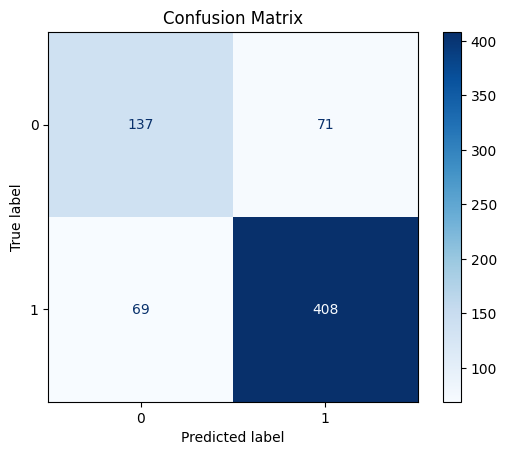

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_xgb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


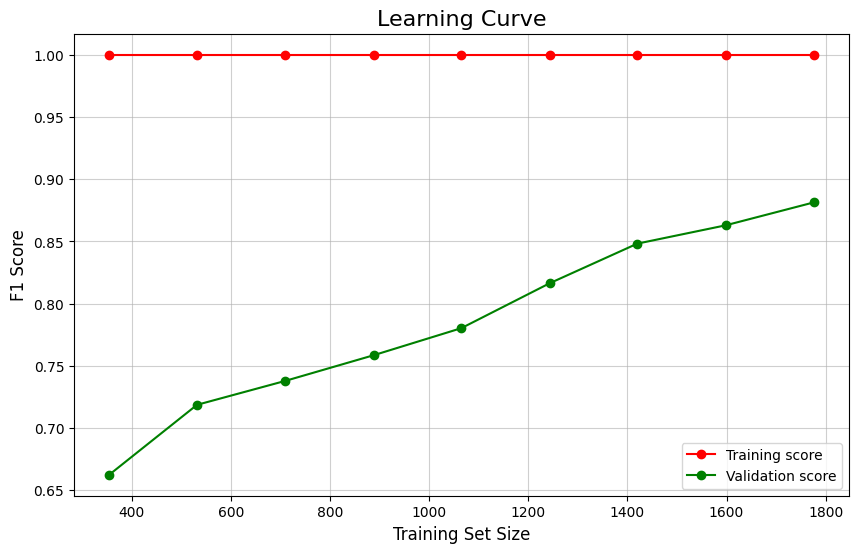

In [18]:
from sklearn.model_selection import learning_curve
import numpy as np

# Plot learning curve
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='f1_weighted', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Training score")
    plt.plot(train_sizes, val_scores_mean, 'o-', color='g', label="Validation score")
    plt.title("Learning Curve", fontsize=16)
    plt.xlabel("Training Set Size", fontsize=12)
    plt.ylabel("F1 Score", fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.6)
    plt.show()

plot_learning_curve(best_xgb_model, X_train, y_train)


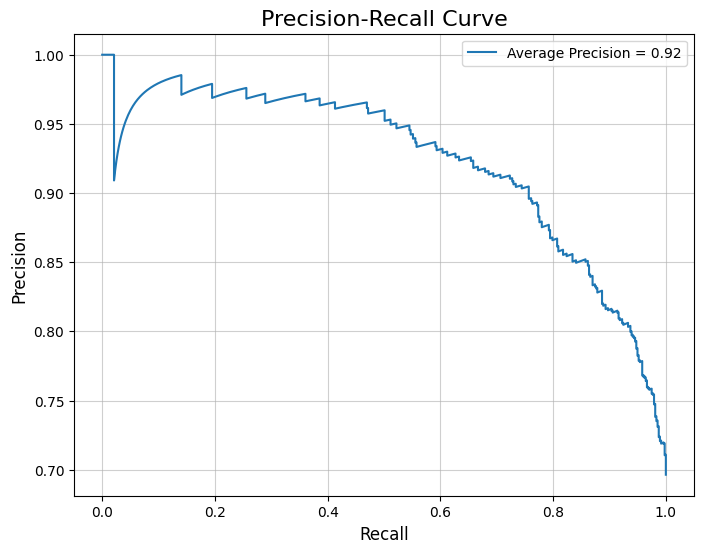

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot precision-recall curve
def plot_precision_recall(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]  # Assuming binary classification
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.2f}")
    plt.title("Precision-Recall Curve", fontsize=16)
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.6)
    plt.show()

plot_precision_recall(best_xgb_model, X_test, y_test)


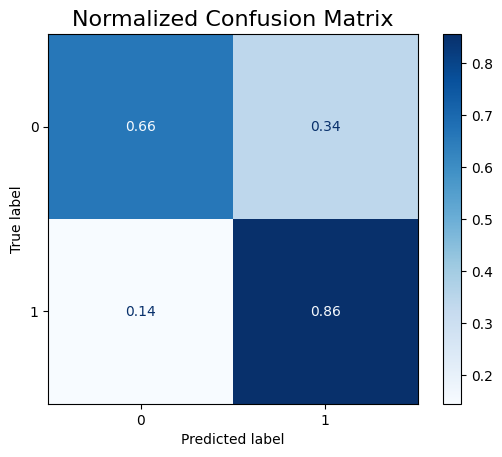

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, normalize='true')
    plt.title("Normalized Confusion Matrix", fontsize=16)
    plt.show()

plot_confusion_matrix(best_xgb_model, X_test, y_test)


Optimizing models...
Optimizing XGBoost...


<ipython-input-5-ae5a48007b06>:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[distance_col] = np.sqrt((df[x2] - df[x1]) ** 2 + (df[y2] - df[y1]) ** 2)
<ipython-input-5-ae5a48007b06>:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[distance_col] = np.sqrt((df[x2] - df[x1]) ** 2 + (df[y2] - df[y1]) ** 2)
<ipython-input-5-ae5a48007b06>:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Optimizing Balanced Random Forest...


/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


Evaluating XGBoost...
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.67       208
           1       0.85      0.90      0.87       477

    accuracy                           0.82       685
   macro avg       0.79      0.76      0.77       685
weighted avg       0.81      0.82      0.81       685



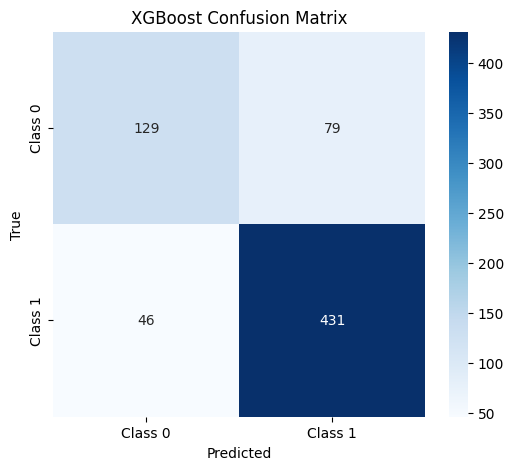

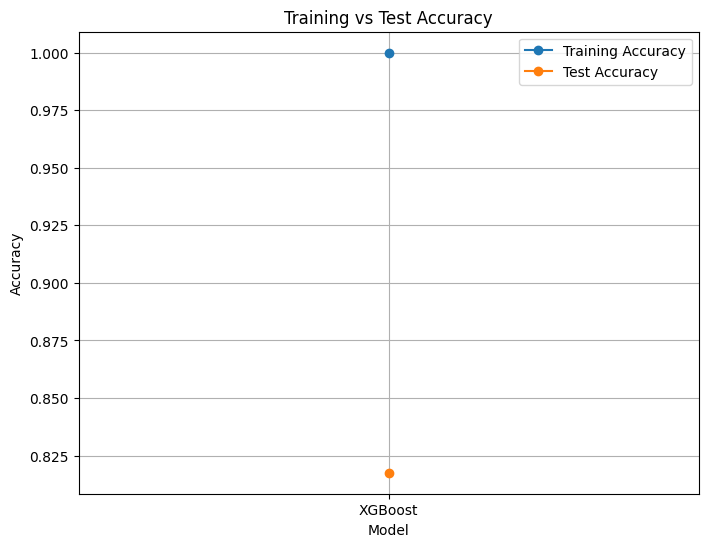

Evaluating Balanced Random Forest...
Balanced Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.62      0.63       208
           1       0.84      0.85      0.84       477

    accuracy                           0.78       685
   macro avg       0.74      0.73      0.74       685
weighted avg       0.78      0.78      0.78       685



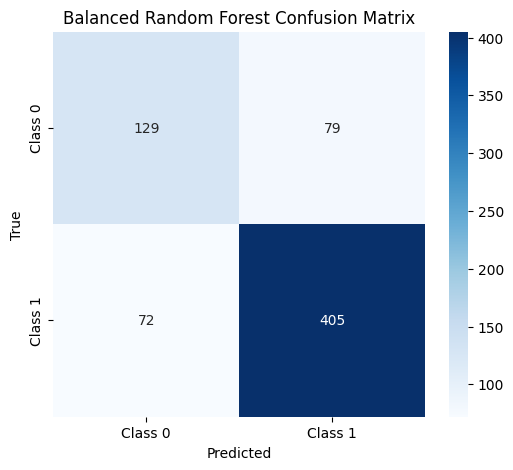

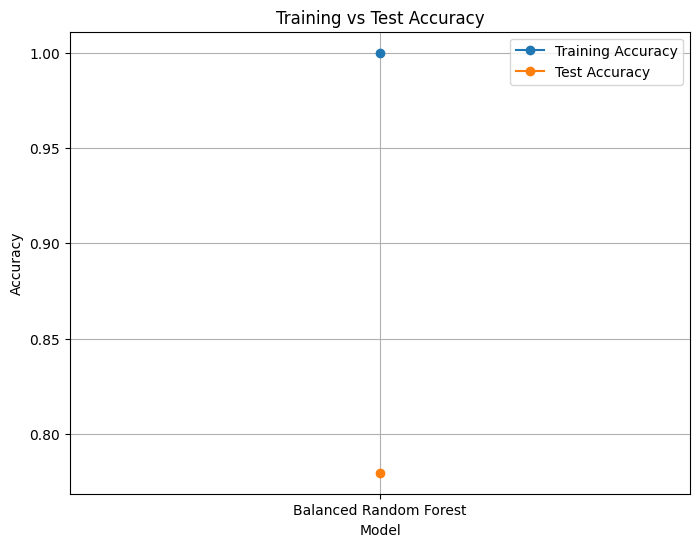

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from imblearn.ensemble import BalancedRandomForestClassifier
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering function (distance computation remains same)
def calculate_distances(df, keypoints):
    for (point1, point2) in itertools.combinations(keypoints, 2):
        x1, y1 = f"{point1}_x", f"{point1}_y"
        x2, y2 = f"{point2}_x", f"{point2}_y"
        distance_col = f"dist_{point1}_{point2}"
        df[distance_col] = np.sqrt((df[x2] - df[x1]) ** 2 + (df[y2] - df[y1]) ** 2)
    return df

def optimize_hyperparameters(X_train, y_train):
    # Define parameter grid for XGBoost
    xgb_params = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'gamma': [0, 0.1, 0.2],
        'scale_pos_weight': [1, 2, 5]
    }
    xgb_model = xgb.XGBClassifier(random_state=42)
    xgb_search = RandomizedSearchCV(
        xgb_model, xgb_params, scoring='f1_macro', n_iter=20, cv=3, random_state=42, n_jobs=-1
    )

    # Define parameter grid for Balanced Random Forest
    brf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt', 'log2', None]
    }
    brf_model = BalancedRandomForestClassifier(random_state=42)
    brf_search = RandomizedSearchCV(
        brf_model, brf_params, scoring='f1_macro', n_iter=20, cv=3, random_state=42, n_jobs=-1
    )

    # Fit models and return best
    print("Optimizing XGBoost...")
    xgb_search.fit(X_train, y_train)
    print("Optimizing Balanced Random Forest...")
    brf_search.fit(X_train, y_train)

    return xgb_search.best_estimator_, brf_search.best_estimator_

def main():
    # Load dataset
    dataset = pd.read_csv('mpii_dataset.csv')

    # Extract keypoints for feature engineering
    keypoints = ['head', 'upper_neck', 'thorax', 'lsho', 'rsho', 'lelb', 'relb',
                 'lwri', 'rwri', 'lhip', 'rhip', 'lknee', 'rknee', 'lankl', 'rankl']
    dataset = calculate_distances(dataset, keypoints)

    # Define features and target
    X, y = dataset.drop(columns=['sport']), dataset['sport']

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Apply SMOTE for oversampling
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Optimize hyperparameters
    print("Optimizing models...")
    xgb_model, brf_model = optimize_hyperparameters(X_train_resampled, y_train_resampled)

    # Evaluate models
    for model_name, model in zip(["XGBoost", "Balanced Random Forest"], [xgb_model, brf_model]):
        print(f"Evaluating {model_name}...")
        y_pred = model.predict(X_test)
        print(f"{model_name} Classification Report:")
        print(classification_report(y_test, y_pred))

        # Confusion matrix for each model
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
        plt.title(f'{model_name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

        # Training vs Test Accuracy for each model
        train_accuracy = model.score(X_train, y_train)
        test_accuracy = model.score(X_test, y_test)

        plt.figure(figsize=(8, 6))
        plt.plot([model_name], [train_accuracy], label='Training Accuracy', marker='o')
        plt.plot([model_name], [test_accuracy], label='Test Accuracy', marker='o')
        plt.title('Training vs Test Accuracy')
        plt.xlabel('Model')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.show()

if __name__ == '__main__':
    main()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Function to print confusion matrix
def print_confusion_matrix(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    print("\t\tPred")
    print("\t\tP0\tP1")
    print(f"True\tT0\t{cm[0, 0]}\t{cm[0, 1]}")
    print(f"\tT1\t{cm[1, 0]}\t{cm[1, 1]}")
    print()

# Load Dataset
data = pd.read_csv('mpii_dataset.csv')
X = data.drop(columns=['sport'])
y = data['sport']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# SMOTE Oversampling with tuned parameters
smote = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Base XGBoost Model
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))

# RandomizedSearchCV for hyperparameter tuning
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 2, 3],
    'lambda': [0, 1, 2]
}

random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist, n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)
best_xgb = random_search.best_estimator_

# Other Models for Voting Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svc_model = SVC(kernel='linear', probability=True, random_state=42)

# Voting Classifier (Hard Voting)
voting_clf = VotingClassifier(estimators=[('xgb', best_xgb), ('rf', rf_model), ('svc', svc_model)], voting='soft')
voting_clf.fit(X_train_smote, y_train_smote)

# Predictions and Evaluation
y_pred = voting_clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print_confusion_matrix(y_test, y_pred)

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # SMOTE for fold
    X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)

    # Fit model on fold
    voting_clf.fit(X_train_fold_smote, y_train_fold_smote)

    # Predict and calculate F1-score for fold
    y_val_pred = voting_clf.predict(X_val_fold)
    fold_f1 = classification_report(y_val_fold, y_val_pred, output_dict=True)['macro avg']['f1-score']
    cv_scores.append(fold_f1)

print(f"\nCross-Validated F1-Score (Macro Avg): {np.mean(cv_scores):.4f}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.68      0.63       208
           1       0.85      0.80      0.82       477

    accuracy                           0.76       685
   macro avg       0.72      0.74      0.73       685
weighted avg       0.77      0.76      0.76       685

		Pred
		P0	P1
True	T0	141	67
	T1	97	380



Fitting 3 folds for each of 30 candidates, totalling 90 fits
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.64      0.68       208
           1       0.85      0.89      0.87       477

    accuracy                           0.81       685
   macro avg       0.78      0.77      0.77       685
weighted avg       0.81      0.81      0.81       685



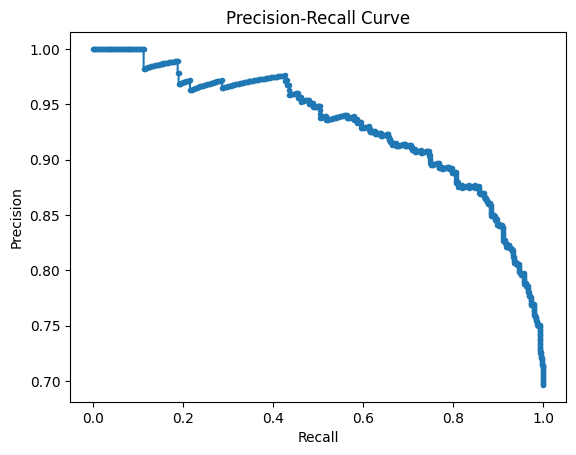

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


Balanced Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.73      0.66       208
           1       0.87      0.79      0.83       477

    accuracy                           0.77       685
   macro avg       0.74      0.76      0.74       685
weighted avg       0.79      0.77      0.78       685



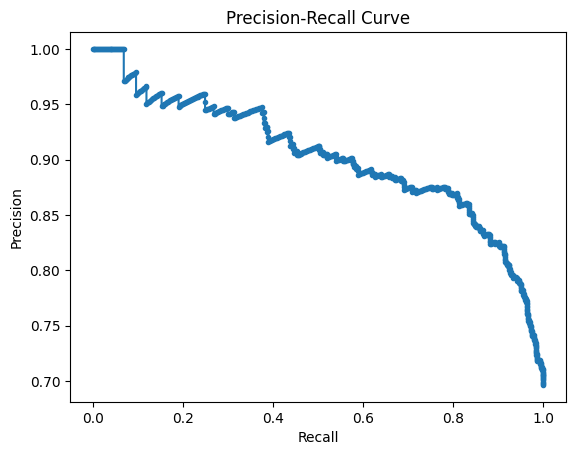

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
import itertools
import matplotlib.pyplot as plt

# distances between body parts
def calculate_distances_fast(df, keypoints):
    distances = {}
    for (point1, point2) in itertools.combinations(keypoints, 2):
        x1, y1 = f"{point1}_x", f"{point1}_y"
        x2, y2 = f"{point2}_x", f"{point2}_y"
        distance_col = f"dist_{point1}_{point2}"
        distances[distance_col] = np.sqrt((df[x2] - df[x1]) ** 2 + (df[y2] - df[y1]) ** 2)
    distances_df = pd.DataFrame(distances)
    return pd.concat([df, distances_df], axis=1)

# angles between three points
def calculate_angles(df, keypoints):
    angles = {}
    for (p1, p2, p3) in itertools.combinations(keypoints, 3):
        x1, y1 = f"{p1}_x", f"{p1}_y"
        x2, y2 = f"{p2}_x", f"{p2}_y"
        x3, y3 = f"{p3}_x", f"{p3}_y"
        angle_col = f"angle_{p1}_{p2}_{p3}"

        vec1_x = df[x1] - df[x2]
        vec1_y = df[y1] - df[y2]
        vec2_x = df[x3] - df[x2]
        vec2_y = df[y3] - df[y2]

        dot_product = vec1_x * vec2_x + vec1_y * vec2_y
        magnitude = (np.sqrt(vec1_x ** 2 + vec1_y ** 2) * np.sqrt(vec2_x ** 2 + vec2_y ** 2)) + 1e-6
        angles[angle_col] = np.arccos(dot_product / magnitude)
    angles_df = pd.DataFrame(angles)
    return pd.concat([df, angles_df], axis=1)

# Function to compute symmetry features
def calculate_symmetry(df):
    symmetries = {}
    for joint in ['sho', 'elb', 'wri', 'hip', 'knee', 'ankl']:
        left = f"l{joint}_x"
        right = f"r{joint}_x"
        symmetries[f"symmetry_{joint}"] = np.abs(df[left] - df[right])
    symmetry_df = pd.DataFrame(symmetries)
    return pd.concat([df, symmetry_df], axis=1)

# Confusion matrix printer
def print_confusion_matrix(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    print("\t\tPred")
    print("\t\tP0\tP1")
    print(f"True\tT0\t{cm[0,0]}\t{cm[0,1]}")
    print(f"\tT1\t{cm[1,0]}\t{cm[1,1]}\n")

    precision = cm[0,0] / (cm[0,0] + cm[1,0]) if cm[0,0] + cm[1,0] else 0.0
    recall = cm[0,0] / (cm[0,0] + cm[0,1]) if cm[0,0] + cm[0,1] else 0.0
    f1 = 2 * precision * recall / (precision + recall) if cm[0,0] > 0 else 0.0
    print(f"Class 0 - Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if cm[1,1] + cm[0,1] else 0.0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if cm[1,1] + cm[1,0] else 0.0
    f1 = 2 * precision * recall / (precision + recall) if cm[1,1] > 0 else 0.0
    print(f"Class 1 - Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}\n")

# Plot Precision-Recall Curve
def plot_pr_curve(y_test, y_scores):
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

# Main code
def main():
    # Load dataset
    dataset = pd.read_csv('mpii_dataset.csv')

    # Extract keypoints for feature engineering
    keypoints = ['head', 'upper_neck', 'thorax', 'lsho', 'rsho', 'lelb', 'relb',
                 'lwri', 'rwri', 'lhip', 'rhip', 'lknee', 'rknee', 'lankl', 'rankl']

    # Add distances, angles, and symmetry features
    dataset = calculate_distances_fast(dataset, keypoints)
    dataset = calculate_angles(dataset, keypoints)
    dataset = calculate_symmetry(dataset)

    # Define features and target
    X, y = dataset.drop(columns=['sport']), dataset['sport']

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Apply ADASYN for oversampling
    adasyn = ADASYN(random_state=42)
    X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

    # XGBoost with hyperparameter tuning
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

    param_dist = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'gamma': [0, 0.1, 0.3],
        'min_child_weight': [1, 3, 5]
    }

    randomized_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,
                                           scoring='f1_macro', n_iter=30, cv=3, verbose=1, random_state=42, n_jobs=-1)
    randomized_search.fit(X_train_resampled, y_train_resampled)

    # Evaluate XGBoost
    best_model = randomized_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]

    print("XGBoost Classification Report:")
    print(classification_report(y_test, y_pred))
    plot_pr_curve(y_test, y_scores)

    # Balanced Random Forest
    brf = BalancedRandomForestClassifier(random_state=42, n_estimators=200, max_depth=7)
    brf.fit(X_train_resampled, y_train_resampled)

    y_pred_brf = brf.predict(X_test)
    y_scores_brf = brf.predict_proba(X_test)[:, 1]

    print("Balanced Random Forest Classification Report:")
    print(classification_report(y_test, y_pred_brf))
    plot_pr_curve(y_test, y_scores_brf)

if __name__ == '__main__':
    main()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.over_sampling import SMOTE

# Load the dataset
file_path = 'dataset.csv'
data = pd.read_csv(file_path)

# Identify joint coordinate columns (all '_x' and '_y' columns)
joint_coordinates = [col for col in data.columns if '_x' in col or '_y' in col]

# Impute missing and negative values with the mean of their respective columns
data_imputed = data.copy()
for col in joint_coordinates:
    # Calculate mean for non-negative values
    mean_value = data_imputed[col][data_imputed[col] >= 0].mean()
    # Replace negatives with the mean
    data_imputed[col] = data_imputed[col].apply(lambda x: mean_value if x < 0 else x)
    # Replace NaN values with the mean
    data_imputed[col].fillna(mean_value, inplace=True)

# Verify that no negative or missing values remain
negative_values_after = (data_imputed[joint_coordinates] < 0).sum().sum()
missing_values_after = data_imputed[joint_coordinates].isnull().sum().sum()

print(f"Negative values remaining: {negative_values_after}")
print(f"Missing values remaining: {missing_values_after}")

# Step 1: Preparing data for training and testing
# Separate features and target
target_column = 'sport'
features = [col for col in data_imputed.columns if col != target_column]
X = data_imputed[features]
y = data_imputed[target_column]

# Step 2: Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the data into train and test sets before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Applying SMOTE to only the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verifying class distribution after oversampling
train_class_distribution = pd.Series(y_train_resampled).value_counts()

# Step 4: Training a Logistic Regression model on the resampled training set
logistic_model_resampled = LogisticRegression(max_iter=500, random_state=42)
logistic_model_resampled.fit(X_train_resampled, y_train_resampled)

# Step 5: Make predictions on the original test set
y_pred_resampled = logistic_model_resampled.predict(X_test)

# Evaluating the model performance
conf_matrix_resampled = confusion_matrix(y_test, y_pred_resampled)
classification_rep_resampled = classification_report(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)


print("Class Distribution in Resampled Training Set:\n", train_class_distribution)
print("\nClassification Report (SMOTE on Train Set):\n", classification_rep_resampled)
print("F1 Score (SMOTE on Train Set):", f1_resampled)


<ipython-input-4-d0ee2796910b>:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_imputed[col].fillna(mean_value, inplace=True)


Negative values remaining: 0
Missing values remaining: 0
Class Distribution in Resampled Training Set:
 sport
0    1269
1    1269
Name: count, dtype: int64

Classification Report (SMOTE on Train Set):
               precision    recall  f1-score   support

           0       0.50      0.68      0.58       139
           1       0.84      0.70      0.76       318

    accuracy                           0.70       457
   macro avg       0.67      0.69      0.67       457
weighted avg       0.73      0.70      0.71       457

F1 Score (SMOTE on Train Set): 0.7623931623931623


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Step 1: Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Reshape the data for 1D CNN
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Step 3: Define the 1D CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Step 4: Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
cnn_history = cnn_model.fit(X_train_reshaped, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Step 6: Evaluate the model
y_pred_cnn = (cnn_model.predict(X_test_reshaped) > 0.5).astype(int).flatten()
conf_matrix_cnn = confusion_matrix(y_test, y_pred_cnn)
classification_rep_cnn = classification_report(y_test, y_pred_cnn, digits=4)
f1_cnn = f1_score(y_test, y_pred_cnn, average='macro')

# Displaying results



/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6820 - loss: 0.6257 - val_accuracy: 0.7068 - val_loss: 0.6101
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7077 - loss: 0.5755 - val_accuracy: 0.7123 - val_loss: 0.5970
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7279 - loss: 0.5560 - val_accuracy: 0.7068 - val_loss: 0.5839
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7512 - loss: 0.5289 - val_accuracy: 0.7452 - val_loss: 0.5715
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7492 - loss: 0.5244 - val_accuracy: 0.7370 - val_loss: 0.5645
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7552 - loss: 0.4998 - val_accuracy: 0.7315 - val_loss: 0.5595
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7613 - loss: 0.5128 - val_accuracy: 0.7123 - val_loss: 0.5637
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7477 - loss: 0.5151 - val_accuracy: 0.7397 - va

ModuleNotFoundError: No module named 'ace_tools'

In [ ]:

print("Classification Report (1D CNN):\n", classification_rep_cnn)
print("Macro F1 Score (1D CNN):", f1_cnn)

Classification Report (1D CNN):
               precision    recall  f1-score   support

           0     0.6195    0.5036    0.5556       139
           1     0.7994    0.8648    0.8308       318

    accuracy                         0.7549       457
   macro avg     0.7094    0.6842    0.6932       457
weighted avg     0.7447    0.7549    0.7471       457

Macro F1 Score (1D CNN): 0.693185632762672


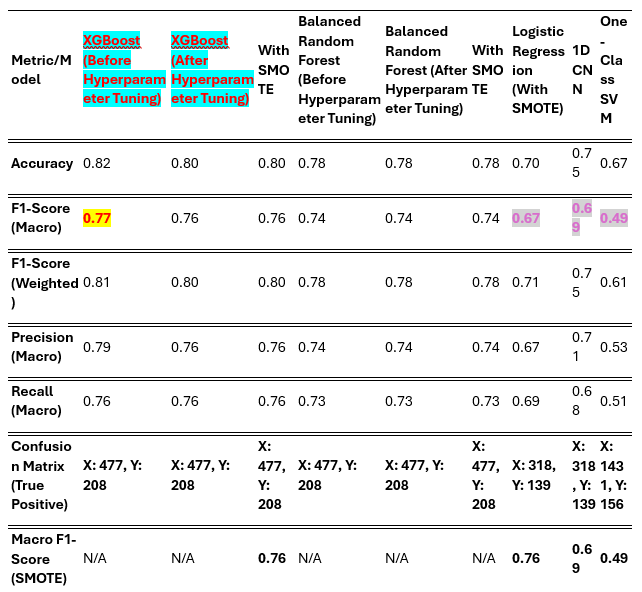


*   XGBoost and Balanced Random Forest are overall the best-performing models, with high F1 scores.
*   XGBoost excels in precision, while Balanced Random Forest has a better overall balance in terms of recall and stability

*   Logistic Regression (with SMOTE) performs well for imbalanced datasets but sacrifices precision to increase recall, leading to a reasonably good weighted F1 score.
*   1D CNN provides a decent balance with strong recall for the minority class and an overall good F1 score but falls short in terms of precision.

*   One-Class SVM struggles the most, with low accuracy and F1 score, likely due to class imbalance and the model's inherent biases in handling such cases.